# APTOS 2019 Multi-Model Benchmark Pipeline (Research)

This notebook benchmarks multiple architectures on the original APTOS 2019 dataset using the fixed best pipeline:

- CLAHE preprocessing
- Rotation augmentation (train only)
- Class-balanced sampling (WeightedRandomSampler as SMOTE-like)
- Stratified split: 80% train / 10% val / 10% test

Models:
1. ResNet50
2. DenseNet121
3. EfficientNet-B0
4. EfficientNet-B3
5. ConvNeXt-Tiny
6. ViT-B/16
7. Fusion: ResNet50 + EfficientNet-B0
8. Fusion: DenseNet121 + EfficientNet-B3
9. Fusion: CNN + ViT

Outputs are saved under `experiments_models/`.

In [1]:
# 1) Imports, global config, reproducibility
import os
import random
import warnings
from pathlib import Path
from copy import deepcopy

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    cohen_kappa_score,
    roc_curve,
    auc,
)

import torchvision.transforms as T
import torchvision.models as models
from PIL import Image

try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    print('⚠ OpenCV not installed. CLAHE will be disabled.')

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Paths
DATA_ROOT = Path('APTOS2019')
TRAIN_CSV = DATA_ROOT / 'train.csv'
IMAGE_DIR = DATA_ROOT / 'train_images'

OUTPUT_ROOT = Path('experiments_models')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Fixed pipeline params (DO NOT CHANGE)
NUM_CLASSES = 5
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
USE_CLAHE = True
USE_ROTATION = True
USE_WEIGHTED_SAMPLER = True

# Training params
MAX_EPOCHS = 100
PATIENCE = 20
BASE_LR = 1e-4
WEIGHT_DECAY = 1e-4
USE_PRETRAINED = True  # Fallback to random init if download is unavailable

print('✓ Environment ready')

Device: cuda
✓ Environment ready


Train: 2929 (80.0%)
Val:   366 (10.0%)
Test:  367 (10.0%)

Train class distribution:
  Class 0: 1444 (49.3%)
  Class 1: 296 (10.1%)
  Class 2: 799 (27.3%)
  Class 3: 154 (5.3%)
  Class 4: 236 (8.1%)

Val class distribution:
  Class 0: 180 (49.2%)
  Class 1: 37 (10.1%)
  Class 2: 100 (27.3%)
  Class 3: 20 (5.5%)
  Class 4: 29 (7.9%)

Test class distribution:
  Class 0: 181 (49.3%)
  Class 1: 37 (10.1%)
  Class 2: 100 (27.2%)
  Class 3: 19 (5.2%)
  Class 4: 30 (8.2%)


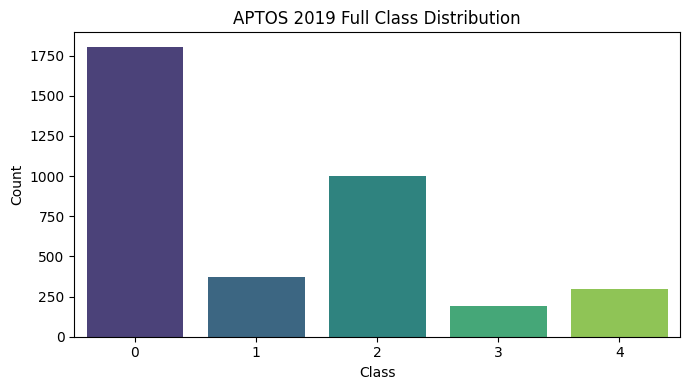

In [2]:
# 2) Load metadata and stratified 80/10/10 split
assert TRAIN_CSV.exists(), f'CSV not found: {TRAIN_CSV}'
assert IMAGE_DIR.exists(), f'Image directory not found: {IMAGE_DIR}'

aptos_df = pd.read_csv(TRAIN_CSV)

if 'id_code' in aptos_df.columns and 'diagnosis' in aptos_df.columns:
    aptos_df['image_path'] = aptos_df['id_code'].astype(str) + '.png'
    aptos_df['label'] = aptos_df['diagnosis'].astype(int)
else:
    assert 'image_path' in aptos_df.columns and 'label' in aptos_df.columns
    aptos_df['label'] = aptos_df['label'].astype(int)

X = aptos_df['image_path'].values
y = aptos_df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f'Train: {len(X_train)} ({len(X_train)/len(X):.1%})')
print(f'Val:   {len(X_val)} ({len(X_val)/len(X):.1%})')
print(f'Test:  {len(X_test)} ({len(X_test)/len(X):.1%})')


def summarize_labels(name, labels):
    counts = pd.Series(labels).value_counts().sort_index()
    total = len(labels)
    print(f'\n{name} class distribution:')
    for c in range(NUM_CLASSES):
        n = int(counts.get(c, 0))
        print(f'  Class {c}: {n} ({100*n/total:.1f}%)')

summarize_labels('Train', y_train)
summarize_labels('Val', y_val)
summarize_labels('Test', y_test)

plt.figure(figsize=(7, 4))
full_counts = pd.Series(y).value_counts().sort_index()
sns.barplot(x=full_counts.index, y=full_counts.values, palette='viridis')
plt.title('APTOS 2019 Full Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'class_distribution.png', dpi=300)
plt.show()

In [3]:
# 3) Fixed preprocessing pipeline (CLAHE + rotation + weighted sampler)


def get_transforms(use_rotation=True):
    eval_tf = T.Compose([
        T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

    if use_rotation:
        train_tf = T.Compose([
            T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            T.RandomRotation(degrees=15, fill=(0, 0, 0)),
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
    else:
        train_tf = eval_tf

    return train_tf, eval_tf


class APTOSDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None, apply_clahe=True):
        self.image_paths = list(image_paths)
        self.labels = np.array(labels, dtype=np.int64)
        self.transform = transform
        self.apply_clahe = apply_clahe

    def __len__(self):
        return len(self.image_paths)

    def _apply_clahe(self, img_rgb):
        if not HAS_CV2:
            return img_rgb
        lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        cl = clahe.apply(l)
        merged = cv2.merge((cl, a, b))
        return cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)

    def __getitem__(self, idx):
        img_path = IMAGE_DIR / self.image_paths[idx]
        if HAS_CV2:
            img_bgr = cv2.imread(str(img_path))
            if img_bgr is None:
                raise FileNotFoundError(f'Could not read image: {img_path}')
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            if self.apply_clahe:
                img_rgb = self._apply_clahe(img_rgb)
            img = Image.fromarray(img_rgb)
        else:
            img = Image.open(img_path).convert('RGB')

        if self.transform is not None:
            img = self.transform(img)

        return img, int(self.labels[idx])


def compute_class_weights_numpy(labels, num_classes=NUM_CLASSES):
    labels = np.asarray(labels, dtype=np.int64)
    counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
    counts[counts == 0] = 1.0
    weights = counts.sum() / (num_classes * counts)
    return weights


def create_weighted_sampler(labels):
    class_weights = compute_class_weights_numpy(labels)
    sample_weights = class_weights[np.asarray(labels, dtype=np.int64)]
    sample_weights = torch.tensor(sample_weights, dtype=torch.double)
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)


def get_batch_size(model_key, device=DEVICE):
    if device.type != 'cuda':
        return 4
    heavy = {'efficientnet_b3', 'convnext_tiny', 'vit_b16', 'fusion_resnet_effnet', 'fusion_densenet_effnet', 'fusion_cnn_vit'}
    return 8 if model_key in heavy else 16


def build_dataloaders(model_key, train_paths, train_labels, val_paths, val_labels, test_paths, test_labels):
    batch_size = get_batch_size(model_key)
    train_tf, eval_tf = get_transforms(use_rotation=USE_ROTATION)

    train_ds = APTOSDataset(train_paths, train_labels, transform=train_tf, apply_clahe=USE_CLAHE)
    val_ds = APTOSDataset(val_paths, val_labels, transform=eval_tf, apply_clahe=USE_CLAHE)
    test_ds = APTOSDataset(test_paths, test_labels, transform=eval_tf, apply_clahe=USE_CLAHE)

    sampler = create_weighted_sampler(train_labels) if USE_WEIGHTED_SAMPLER else None

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=(sampler is None), sampler=sampler, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    return train_loader, val_loader, test_loader, batch_size

In [4]:
# 4) Model builders (single + fusion)


def safe_init(builder, weight_enum=None):
    if not USE_PRETRAINED or weight_enum is None:
        return builder(weights=None)
    try:
        return builder(weights=weight_enum.DEFAULT)
    except Exception as exc:
        print(f'⚠ Pretrained weights unavailable ({builder.__name__}): {exc}. Falling back to random init.')
        return builder(weights=None)


def build_resnet50_classifier(num_classes):
    model = safe_init(models.resnet50, models.ResNet50_Weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def build_densenet121_classifier(num_classes):
    model = safe_init(models.densenet121, models.DenseNet121_Weights)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model


def build_efficientnet_b0_classifier(num_classes):
    model = safe_init(models.efficientnet_b0, models.EfficientNet_B0_Weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def build_efficientnet_b3_classifier(num_classes):
    model = safe_init(models.efficientnet_b3, models.EfficientNet_B3_Weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


def build_convnext_tiny_classifier(num_classes):
    model = safe_init(models.convnext_tiny, models.ConvNeXt_Tiny_Weights)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model


def build_vit_b16_classifier(num_classes):
    model = safe_init(models.vit_b_16, models.ViT_B_16_Weights)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    return model


def build_resnet50_features():
    model = safe_init(models.resnet50, models.ResNet50_Weights)
    dim = model.fc.in_features
    model.fc = nn.Identity()
    return model, dim


def build_densenet121_features():
    model = safe_init(models.densenet121, models.DenseNet121_Weights)
    dim = model.classifier.in_features
    model.classifier = nn.Identity()
    return model, dim


def build_efficientnet_b0_features():
    model = safe_init(models.efficientnet_b0, models.EfficientNet_B0_Weights)
    dim = model.classifier[1].in_features
    model.classifier[1] = nn.Identity()
    return model, dim


def build_efficientnet_b3_features():
    model = safe_init(models.efficientnet_b3, models.EfficientNet_B3_Weights)
    dim = model.classifier[1].in_features
    model.classifier[1] = nn.Identity()
    return model, dim


def build_vit_b16_features():
    model = safe_init(models.vit_b_16, models.ViT_B_16_Weights)
    dim = model.heads.head.in_features
    model.heads.head = nn.Identity()
    return model, dim


class FeatureFusionModel(nn.Module):
    def __init__(self, backbone_a, dim_a, backbone_b, dim_b, num_classes):
        super().__init__()
        self.backbone_a = backbone_a
        self.backbone_b = backbone_b
        self.classifier = nn.Sequential(
            nn.Linear(dim_a + dim_b, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        fa = self.backbone_a(x)
        fb = self.backbone_b(x)
        if fa.ndim > 2:
            fa = torch.flatten(fa, 1)
        if fb.ndim > 2:
            fb = torch.flatten(fb, 1)
        fused = torch.cat([fa, fb], dim=1)
        return self.classifier(fused)


MODEL_SPECS = {
    'resnet50': ('resnet50', build_resnet50_classifier),
    'densenet121': ('densenet121', build_densenet121_classifier),
    'efficientnet_b0': ('efficientnet_b0', build_efficientnet_b0_classifier),
    'efficientnet_b3': ('efficientnet_b3', build_efficientnet_b3_classifier),
    'convnext_tiny': ('convnext_tiny', build_convnext_tiny_classifier),
    'vit_b16': ('vit_b16', build_vit_b16_classifier),
    'fusion_resnet_effnet': ('fusion_resnet_effnet', None),
    'fusion_densenet_effnet': ('fusion_densenet_effnet', None),
    'fusion_cnn_vit': ('fusion_cnn_vit', None),
}


def build_model(model_key, num_classes=NUM_CLASSES):
    if model_key == 'fusion_resnet_effnet':
        a, da = build_resnet50_features()
        b, db = build_efficientnet_b0_features()
        model = FeatureFusionModel(a, da, b, db, num_classes)
    elif model_key == 'fusion_densenet_effnet':
        a, da = build_densenet121_features()
        b, db = build_efficientnet_b3_features()
        model = FeatureFusionModel(a, da, b, db, num_classes)
    elif model_key == 'fusion_cnn_vit':
        a, da = build_resnet50_features()  # CNN backbone
        b, db = build_vit_b16_features()   # Transformer head/branch
        model = FeatureFusionModel(a, da, b, db, num_classes)
    else:
        _, builder = MODEL_SPECS[model_key]
        model = builder(num_classes)

    return model.to(DEVICE)


print('Models configured:', list(MODEL_SPECS.keys()))

Models configured: ['resnet50', 'densenet121', 'efficientnet_b0', 'efficientnet_b3', 'convnext_tiny', 'vit_b16', 'fusion_resnet_effnet', 'fusion_densenet_effnet', 'fusion_cnn_vit']


In [5]:
# 5) Metrics


def compute_specificity_macro(cm):
    cm = np.asarray(cm)
    total = cm.sum()
    specs = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = total - tp - fp - fn
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return float(np.mean(specs))


def compute_metrics(y_true, y_prob, avg_loss, num_classes=NUM_CLASSES):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_prob = np.asarray(y_prob, dtype=np.float32)
    y_pred = y_prob.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specificity = compute_specificity_macro(cm)

    try:
        y_true_oh = np.eye(num_classes)[y_true]
        roc_auc = roc_auc_score(y_true_oh, y_prob, multi_class='ovr')
    except Exception:
        roc_auc = float('nan')

    try:
        qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    except Exception:
        qwk = float('nan')

    return {
        'loss': float(avg_loss),
        'accuracy': float(acc),
        'precision_macro': float(prec_macro),
        'recall_macro': float(rec_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(prec_weighted),
        'recall_weighted': float(rec_weighted),
        'f1_weighted': float(f1_weighted),
        'specificity': float(specificity),
        'roc_auc': float(roc_auc),
        'qwk': float(qwk),
        'confusion_matrix': cm,
    }

In [6]:
# 6) Training and checkpoint utilities (resume + early stopping)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    n_samples = 0
    all_labels, all_probs = [], []

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            logits = model(imgs)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        bs = labels.size(0)
        running_loss += loss.item() * bs
        n_samples += bs

        probs = F.softmax(logits.detach(), dim=1)
        all_labels.append(labels.detach().cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    avg_loss = running_loss / max(1, n_samples)
    y_true = np.concatenate(all_labels, axis=0)
    y_prob = np.concatenate(all_probs, axis=0)
    metrics = compute_metrics(y_true, y_prob, avg_loss)
    return metrics, y_true, y_prob


def train_model(model_key, model, train_loader, val_loader, exp_dir,
                max_epochs=MAX_EPOCHS, patience=PATIENCE):
    exp_dir = Path(exp_dir)
    exp_dir.mkdir(parents=True, exist_ok=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    ckpt_path = exp_dir / 'resume_checkpoint.pth'
    best_path = exp_dir / 'best_model.pth'

    history = {
        'epoch': [],
        'train_loss': [], 'val_loss': [],
        'train_accuracy': [], 'val_accuracy': [],
        'train_f1_macro': [], 'val_f1_macro': [],
        'train_qwk': [], 'val_qwk': [],
        'lr': [],
    }

    best_qwk = -1.0
    best_epoch = 0
    start_epoch = 0
    epochs_no_improve = 0

    # Resume if checkpoint exists
    if ckpt_path.exists():
        ckpt = torch.load(str(ckpt_path), map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        history = ckpt['history']
        start_epoch = ckpt['epoch'] + 1
        best_qwk = ckpt['best_qwk']
        best_epoch = ckpt['best_epoch']
        epochs_no_improve = ckpt.get('epochs_no_improve', 0)
        print(f'↻ Resumed {model_key} from epoch {start_epoch}')

    for epoch in range(start_epoch, max_epochs):
        train_metrics, _, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_metrics, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_metrics['loss'])
        history['val_loss'].append(val_metrics['loss'])
        history['train_accuracy'].append(train_metrics['accuracy'])
        history['val_accuracy'].append(val_metrics['accuracy'])
        history['train_f1_macro'].append(train_metrics['f1_macro'])
        history['val_f1_macro'].append(val_metrics['f1_macro'])
        history['train_qwk'].append(train_metrics['qwk'])
        history['val_qwk'].append(val_metrics['qwk'])
        history['lr'].append(current_lr)

        val_qwk = val_metrics['qwk']
        print(
            f"{model_key} | Epoch {epoch+1}/{max_epochs} | "
            f"Train Loss {train_metrics['loss']:.4f} | Val Loss {val_metrics['loss']:.4f} | "
            f"Val QWK {val_qwk:.4f}"
        )

        # Save resume checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history,
            'best_qwk': best_qwk,
            'best_epoch': best_epoch,
            'epochs_no_improve': epochs_no_improve,
        }, str(ckpt_path))

        # Save best model by val QWK
        if val_qwk > best_qwk:
            best_qwk = val_qwk
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save({
                'epoch': best_epoch,
                'model_state_dict': deepcopy(model.state_dict()),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_qwk': best_qwk,
            }, str(best_path))
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'Early stopping triggered for {model_key} (patience={patience}).')
            break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(exp_dir / 'training_log.csv', index=False)
    return history, best_epoch, best_qwk

In [ ]:
# 7) Evaluation and plotting utilities


def evaluate_split(model, loader, criterion):
    model.eval()
    all_labels, all_probs = [], []
    running_loss, n_samples = 0.0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            logits = model(imgs)
            loss = criterion(logits, labels)

            bs = labels.size(0)
            running_loss += loss.item() * bs
            n_samples += bs

            probs = F.softmax(logits, dim=1)
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    avg_loss = running_loss / max(1, n_samples)
    y_true = np.concatenate(all_labels, axis=0)
    y_prob = np.concatenate(all_probs, axis=0)
    metrics = compute_metrics(y_true, y_prob, avg_loss)
    return metrics, y_true, y_prob


def plot_training_curves(history, plots_dir, best_epoch=None, plot_upto_best=False, suffix=''):
    plots_dir = Path(plots_dir)
    plots_dir.mkdir(parents=True, exist_ok=True)

    epochs = history['epoch']
    train_loss = history['train_loss']
    val_loss = history['val_loss']
    train_acc = history['train_accuracy']
    val_acc = history['val_accuracy']
    train_f1 = history['train_f1_macro']
    val_f1 = history['val_f1_macro']
    train_qwk = history['train_qwk']
    val_qwk = history['val_qwk']

    if plot_upto_best and best_epoch is not None and best_epoch > 0:
        cut = min(best_epoch, len(epochs))
        epochs = epochs[:cut]
        train_loss = train_loss[:cut]
        val_loss = val_loss[:cut]
        train_acc = train_acc[:cut]
        val_acc = val_acc[:cut]
        train_f1 = train_f1[:cut]
        val_f1 = val_f1[:cut]
        train_qwk = train_qwk[:cut]
        val_qwk = val_qwk[:cut]

    def _plot(y_train, y_val, ylabel, title, fname):
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, y_train, label='Train')
        plt.plot(epochs, y_val, label='Validation')
        if best_epoch is not None and best_epoch > 0:
            plt.axvline(best_epoch, color='red', linestyle='--', alpha=0.8, label=f'Best Epoch ({best_epoch})')
        plt.xlabel('Epoch')
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(plots_dir / f"{fname}{suffix}.png", dpi=300)
        plt.close()

    _plot(train_loss, val_loss, 'Loss', 'Loss Curve', 'loss_curve')
    _plot(train_acc, val_acc, 'Accuracy', 'Accuracy Curve', 'accuracy_curve')
    _plot(train_f1, val_f1, 'F1 Macro', 'F1 Curve', 'f1_curve')
    _plot(train_qwk, val_qwk, 'QWK', 'QWK Curve', 'qwk_curve')


def plot_confusion_matrix_png(cm, out_file, title='Confusion Matrix'):
    plt.figure(figsize=(7, 6))
    cm = np.asarray(cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(out_file, dpi=300)
    plt.close()


def plot_roc_curve_png(y_true, y_prob, out_file, title='ROC Curves'):
    n_classes = y_prob.shape[1]
    y_true_oh = np.eye(n_classes)[y_true]

    plt.figure(figsize=(8, 6))
    colors = plt.cm.Set1(np.linspace(0, 1, n_classes))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_oh[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'Class {i} (AUC={roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_file, dpi=300)
    plt.close()

In [ ]:
# 8) End-to-end benchmark runner


def train_and_evaluate_model(model_key):
    folder_name, _ = MODEL_SPECS[model_key]
    exp_dir = OUTPUT_ROOT / folder_name
    plots_dir = exp_dir / 'plots'
    exp_dir.mkdir(parents=True, exist_ok=True)
    plots_dir.mkdir(parents=True, exist_ok=True)

    train_loader, val_loader, test_loader, batch_size = build_dataloaders(
        model_key,
        X_train, y_train,
        X_val, y_val,
        X_test, y_test,
    )

    model = build_model(model_key)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n=== {model_key} | Batch size={batch_size} | Params={n_params:,} ===')

    history, best_epoch, best_val_qwk = train_model(
        model_key, model, train_loader, val_loader, exp_dir,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
    )

    # Load best model for final evaluation
    best_ckpt = torch.load(exp_dir / 'best_model.pth', map_location=DEVICE)
    model.load_state_dict(best_ckpt['model_state_dict'])

    criterion = nn.CrossEntropyLoss()
    train_metrics, _, _ = evaluate_split(model, train_loader, criterion)
    val_metrics, _, _ = evaluate_split(model, val_loader, criterion)
    test_metrics, y_true_test, y_prob_test = evaluate_split(model, test_loader, criterion)

    # Save metrics table
    metrics_rows = []
    for split_name, m in [('train', train_metrics), ('val', val_metrics), ('test', test_metrics)]:
        metrics_rows.append({
            'split': split_name,
            'loss': m['loss'],
            'accuracy': m['accuracy'],
            'precision_macro': m['precision_macro'],
            'recall_macro': m['recall_macro'],
            'f1_macro': m['f1_macro'],
            'precision_weighted': m['precision_weighted'],
            'recall_weighted': m['recall_weighted'],
            'f1_weighted': m['f1_weighted'],
            'specificity': m['specificity'],
            'roc_auc': m['roc_auc'],
            'qwk': m['qwk'],
        })

    metrics_df = pd.DataFrame(metrics_rows)
    metrics_df.to_csv(exp_dir / 'metrics.csv', index=False)

    # Plots
    plot_training_curves(history, plots_dir, best_epoch=best_epoch, plot_upto_best=False, suffix='')
    plot_training_curves(history, plots_dir, best_epoch=best_epoch, plot_upto_best=True, suffix='_upto_best')

    cm_file_root = exp_dir / 'confusion_matrix.png'
    roc_file_root = exp_dir / 'roc_curve.png'
    plot_confusion_matrix_png(test_metrics['confusion_matrix'], cm_file_root, title=f'{model_key} Confusion Matrix')
    plot_roc_curve_png(y_true_test, y_prob_test, roc_file_root, title=f'{model_key} ROC Curves')

    # Also keep copies inside plots/
    plot_confusion_matrix_png(test_metrics['confusion_matrix'], plots_dir / 'confusion_matrix.png', title=f'{model_key} Confusion Matrix')
    plot_roc_curve_png(y_true_test, y_prob_test, plots_dir / 'roc_curve.png', title=f'{model_key} ROC Curves')

    return {
        'model': model_key,
        'best_epoch': int(best_epoch),
        'best_val_qwk': float(best_val_qwk),
        'test_accuracy': float(test_metrics['accuracy']),
        'test_f1': float(test_metrics['f1_macro']),
        'test_qwk': float(test_metrics['qwk']),
        'test_auc': float(test_metrics['roc_auc']),
    }


def run_benchmark(model_keys=None):
    if model_keys is None:
        model_keys = list(MODEL_SPECS.keys())

    results = []
    for key in model_keys:
        results.append(train_and_evaluate_model(key))

    summary_df = pd.DataFrame(results)
    summary_df = summary_df.sort_values(by='test_qwk', ascending=False).reset_index(drop=True)

    # Save summary
    summary_df.to_csv(OUTPUT_ROOT / 'model_comparison.csv', index=False)

    # Required final table
    final_cols = ['model', 'best_epoch', 'test_accuracy', 'test_f1', 'test_qwk', 'test_auc']
    display_df = summary_df[final_cols].copy()

    print('\nFinal comparison table:')
    display(display_df)

    # Best model + top 3
    best_row = summary_df.iloc[0]
    print('\nBest model (by QWK):')
    print(f"  {best_row['model']} | QWK={best_row['test_qwk']:.4f} | Acc={best_row['test_accuracy']:.4f} | F1={best_row['test_f1']:.4f} | AUC={best_row['test_auc']:.4f}")

    print('\nTop 3 models by QWK:')
    top3 = summary_df.head(3)
    for i, row in top3.iterrows():
        print(f"  {i+1}. {row['model']} | QWK={row['test_qwk']:.4f}")

    # Final bar chart
    plt.figure(figsize=(11, 5))
    sns.barplot(data=summary_df, x='model', y='test_qwk', palette='viridis')
    plt.xticks(rotation=30, ha='right')
    plt.title('Model Comparison by Test QWK')
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / 'final_comparison_bar_chart.png', dpi=300)
    plt.show()

    return summary_df

## Run Options

You can either run all 9 models or run only a subset (for faster experiments).

- `all_models = list(MODEL_SPECS.keys())`
- `subset_models = ['resnet50', 'efficientnet_b0', 'fusion_cnn_vit']`

Selected models: ['resnet50', 'densenet121', 'efficientnet_b0', 'efficientnet_b3', 'convnext_tiny', 'vit_b16', 'fusion_resnet_effnet', 'fusion_densenet_effnet', 'fusion_cnn_vit']


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\PC1/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100.0%



=== resnet50 | Batch size=16 | Params=23,518,277 ===
resnet50 | Epoch 1/100 | Train Loss 1.0633 | Val Loss 0.8223 | Val QWK 0.7818
resnet50 | Epoch 2/100 | Train Loss 0.5853 | Val Loss 0.7024 | Val QWK 0.7870
resnet50 | Epoch 3/100 | Train Loss 0.3876 | Val Loss 0.8339 | Val QWK 0.8132
resnet50 | Epoch 4/100 | Train Loss 0.2838 | Val Loss 0.7726 | Val QWK 0.8241
resnet50 | Epoch 5/100 | Train Loss 0.2447 | Val Loss 0.7703 | Val QWK 0.8209
resnet50 | Epoch 6/100 | Train Loss 0.1903 | Val Loss 0.8813 | Val QWK 0.7970
resnet50 | Epoch 7/100 | Train Loss 0.1987 | Val Loss 0.9555 | Val QWK 0.8491
resnet50 | Epoch 8/100 | Train Loss 0.1767 | Val Loss 1.0722 | Val QWK 0.8341
resnet50 | Epoch 9/100 | Train Loss 0.1405 | Val Loss 1.1726 | Val QWK 0.8219
resnet50 | Epoch 10/100 | Train Loss 0.1404 | Val Loss 1.2362 | Val QWK 0.8232
resnet50 | Epoch 11/100 | Train Loss 0.1150 | Val Loss 1.2049 | Val QWK 0.8175
resnet50 | Epoch 12/100 | Train Loss 0.0958 | Val Loss 1.2871 | Val QWK 0.8359
resnet5

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to C:\Users\PC1/.cache\torch\hub\checkpoints\convnext_tiny-983f1562.pth
100.0%



=== convnext_tiny | Batch size=8 | Params=27,823,973 ===
convnext_tiny | Epoch 1/100 | Train Loss 0.8204 | Val Loss 0.7122 | Val QWK 0.8153
convnext_tiny | Epoch 2/100 | Train Loss 0.4940 | Val Loss 0.6789 | Val QWK 0.8696
convnext_tiny | Epoch 3/100 | Train Loss 0.3326 | Val Loss 0.7649 | Val QWK 0.8515
convnext_tiny | Epoch 4/100 | Train Loss 0.2707 | Val Loss 1.0118 | Val QWK 0.8851
convnext_tiny | Epoch 5/100 | Train Loss 0.2285 | Val Loss 1.0823 | Val QWK 0.8568
convnext_tiny | Epoch 6/100 | Train Loss 0.1948 | Val Loss 1.3904 | Val QWK 0.8503
convnext_tiny | Epoch 7/100 | Train Loss 0.1587 | Val Loss 1.4456 | Val QWK 0.8539
convnext_tiny | Epoch 8/100 | Train Loss 0.1578 | Val Loss 1.5139 | Val QWK 0.8576
convnext_tiny | Epoch 9/100 | Train Loss 0.1154 | Val Loss 1.5218 | Val QWK 0.8603
convnext_tiny | Epoch 10/100 | Train Loss 0.1214 | Val Loss 1.4064 | Val QWK 0.8554
convnext_tiny | Epoch 11/100 | Train Loss 0.1410 | Val Loss 1.3065 | Val QWK 0.8744
convnext_tiny | Epoch 12/10

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\PC1/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth
100.0%



=== vit_b16 | Batch size=8 | Params=85,802,501 ===
vit_b16 | Epoch 1/100 | Train Loss 1.2904 | Val Loss 1.1445 | Val QWK 0.6070
vit_b16 | Epoch 2/100 | Train Loss 0.9752 | Val Loss 0.7689 | Val QWK 0.8332
vit_b16 | Epoch 3/100 | Train Loss 0.8357 | Val Loss 0.9440 | Val QWK 0.7504
vit_b16 | Epoch 4/100 | Train Loss 0.7960 | Val Loss 0.8262 | Val QWK 0.8309
vit_b16 | Epoch 5/100 | Train Loss 0.7271 | Val Loss 0.7948 | Val QWK 0.8418
vit_b16 | Epoch 6/100 | Train Loss 0.6385 | Val Loss 0.8540 | Val QWK 0.8427
vit_b16 | Epoch 7/100 | Train Loss 0.6086 | Val Loss 0.7071 | Val QWK 0.8304
vit_b16 | Epoch 8/100 | Train Loss 0.5427 | Val Loss 0.8300 | Val QWK 0.8468
vit_b16 | Epoch 9/100 | Train Loss 0.5356 | Val Loss 0.8668 | Val QWK 0.8348
vit_b16 | Epoch 10/100 | Train Loss 0.4634 | Val Loss 1.0142 | Val QWK 0.8048
vit_b16 | Epoch 11/100 | Train Loss 0.4279 | Val Loss 0.9546 | Val QWK 0.8240
vit_b16 | Epoch 12/100 | Train Loss 0.3967 | Val Loss 1.0064 | Val QWK 0.8287
vit_b16 | Epoch 13/10

,model,best_epoch,test_accuracy,test_f1,test_qwk,test_auc
0,fusion_cnn_vit,14,0.831063,0.658568,0.922838,0.929435
1,fusion_resnet_effnet,46,0.836512,0.673598,0.909224,0.931929
2,efficientnet_b0,27,0.825613,0.657835,0.908045,0.897219
3,convnext_tiny,4,0.790191,0.647859,0.906201,0.946705
4,fusion_densenet_effnet,60,0.844687,0.666294,0.905615,0.944139
5,resnet50,29,0.817439,0.653790,0.898639,0.918999
6,densenet121,19,0.825613,0.687990,0.897299,0.931317
7,vit_b16,41,0.825613,0.631452,0.895580,0.928276
8,efficientnet_b3,2,0.738420,0.605110,0.886010,0.939061



Best model (by QWK):
  fusion_cnn_vit | QWK=0.9228 | Acc=0.8311 | F1=0.6586 | AUC=0.9294

Top 3 models by QWK:
  1. fusion_cnn_vit | QWK=0.9228
  2. fusion_resnet_effnet | QWK=0.9092
  3. efficientnet_b0 | QWK=0.9080


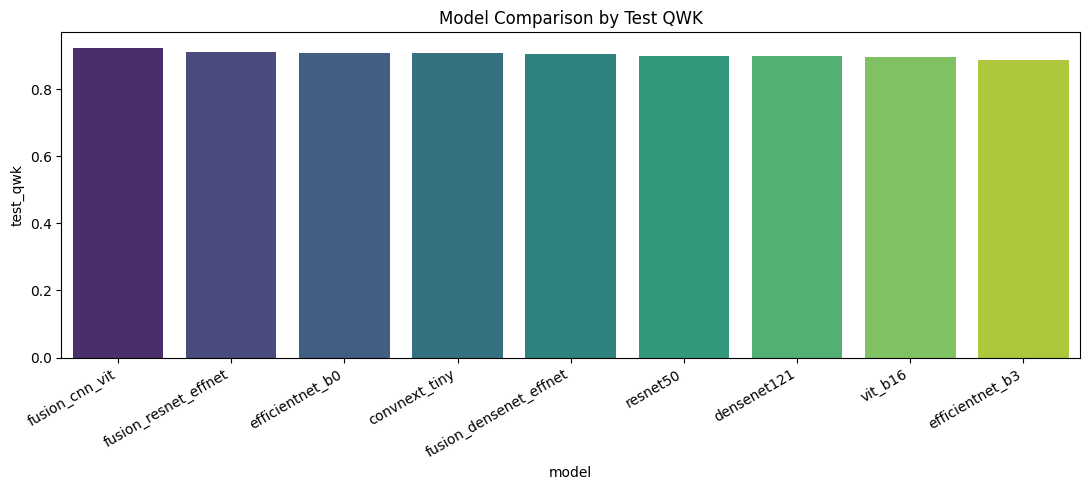

,model,best_epoch,best_val_qwk,test_accuracy,test_f1,test_qwk,test_auc
0,fusion_cnn_vit,14,0.856460,0.831063,0.658568,0.922838,0.929435
1,fusion_resnet_effnet,46,0.874784,0.836512,0.673598,0.909224,0.931929
2,efficientnet_b0,27,0.864557,0.825613,0.657835,0.908045,0.897219
3,convnext_tiny,4,0.885095,0.790191,0.647859,0.906201,0.946705
4,fusion_densenet_effnet,60,0.872007,0.844687,0.666294,0.905615,0.944139


In [9]:
# 9) Execute benchmark
all_models = list(MODEL_SPECS.keys())

# If you only want to run specific models, edit this list:
selected_models = all_models
# Example:
# selected_models = ['resnet50', 'densenet121', 'efficientnet_b0']
# selected_models = ['fusion_resnet_effnet', 'fusion_densenet_effnet', 'fusion_cnn_vit']

print('Selected models:', selected_models)

# Run
summary_df = run_benchmark(selected_models)
summary_df.head()

In [10]:
# 10) Re-draw plots from existing logs/checkpoints (NO retraining)
# This cell only reads saved files under experiments_models/ and regenerates curves.


def redraw_curves_from_saved_artifacts(output_root=OUTPUT_ROOT):
    output_root = Path(output_root)

    expected_models = list(MODEL_SPECS.keys()) if 'MODEL_SPECS' in globals() else []
    if expected_models:
        model_dirs = [(m, output_root / m) for m in expected_models]
    else:
        model_dirs = [(p.name, p) for p in output_root.iterdir() if p.is_dir()]

    def _draw_pair(epochs, y_train, y_val, ylabel, title, save_path, best_epoch=None):
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, y_train, label='Train')
        plt.plot(epochs, y_val, label='Validation')
        if best_epoch is not None and best_epoch > 0:
            plt.axvline(best_epoch, color='red', linestyle='--', alpha=0.8, label=f'Best Epoch ({best_epoch})')
        plt.xlabel('Epoch')
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.close()

    generated = []
    skipped = []

    for model_key, model_dir in model_dirs:
        if not model_dir.exists():
            skipped.append((model_key, 'model folder not found'))
            continue

        log_path = model_dir / 'training_log.csv'
        ckpt_path = model_dir / 'best_model.pth'
        plots_dir = model_dir / 'plots'
        plots_dir.mkdir(parents=True, exist_ok=True)

        if not log_path.exists():
            skipped.append((model_key, 'training_log.csv not found'))
            continue

        hist_df = pd.read_csv(log_path)
        if hist_df.empty:
            skipped.append((model_key, 'training_log.csv is empty'))
            continue

        required_cols = [
            'epoch',
            'train_loss', 'val_loss',
            'train_accuracy', 'val_accuracy',
            'train_f1_macro', 'val_f1_macro',
            'train_qwk', 'val_qwk',
        ]
        missing_cols = [c for c in required_cols if c not in hist_df.columns]
        if missing_cols:
            skipped.append((model_key, f'missing columns: {missing_cols}'))
            continue

        best_epoch = None
        if ckpt_path.exists():
            try:
                ckpt = torch.load(str(ckpt_path), map_location='cpu')
                if isinstance(ckpt, dict):
                    best_epoch = int(ckpt.get('epoch', 0))
                    if best_epoch <= 0 and 'best_epoch' in ckpt:
                        best_epoch = int(ckpt.get('best_epoch', 0))
                    if best_epoch <= 0:
                        best_epoch = None
            except Exception:
                best_epoch = None

        epochs = hist_df['epoch'].tolist()
        train_loss = hist_df['train_loss'].tolist()
        val_loss = hist_df['val_loss'].tolist()
        train_acc = hist_df['train_accuracy'].tolist()
        val_acc = hist_df['val_accuracy'].tolist()
        train_f1 = hist_df['train_f1_macro'].tolist()
        val_f1 = hist_df['val_f1_macro'].tolist()
        train_qwk = hist_df['train_qwk'].tolist()
        val_qwk = hist_df['val_qwk'].tolist()

        # Full curves (all epochs)
        _draw_pair(epochs, train_loss, val_loss, 'Loss', f'{model_key} Loss Curve', plots_dir / 'loss_curve.png', best_epoch)
        _draw_pair(epochs, train_acc, val_acc, 'Accuracy', f'{model_key} Accuracy Curve', plots_dir / 'accuracy_curve.png', best_epoch)
        _draw_pair(epochs, train_f1, val_f1, 'F1 Macro', f'{model_key} F1 Curve', plots_dir / 'f1_curve.png', best_epoch)
        _draw_pair(epochs, train_qwk, val_qwk, 'QWK', f'{model_key} QWK Curve', plots_dir / 'qwk_curve.png', best_epoch)

        # Curves up to best epoch
        if best_epoch is not None:
            cut = min(best_epoch, len(epochs))
            e = epochs[:cut]
            _draw_pair(e, train_loss[:cut], val_loss[:cut], 'Loss', f'{model_key} Loss Curve (Up to Best Epoch)', plots_dir / 'loss_curve_upto_best.png', best_epoch)
            _draw_pair(e, train_acc[:cut], val_acc[:cut], 'Accuracy', f'{model_key} Accuracy Curve (Up to Best Epoch)', plots_dir / 'accuracy_curve_upto_best.png', best_epoch)
            _draw_pair(e, train_f1[:cut], val_f1[:cut], 'F1 Macro', f'{model_key} F1 Curve (Up to Best Epoch)', plots_dir / 'f1_curve_upto_best.png', best_epoch)
            _draw_pair(e, train_qwk[:cut], val_qwk[:cut], 'QWK', f'{model_key} QWK Curve (Up to Best Epoch)', plots_dir / 'qwk_curve_upto_best.png', best_epoch)

        generated.append(model_key)

    print(f'✓ Re-drawing completed for {len(generated)} model(s).')
    if generated:
        print('Generated:', generated)
    if skipped:
        print('\nSkipped:')
        for name, reason in skipped:
            print(f'- {name}: {reason}')


# Run only this function to regenerate training curves from saved artifacts
redraw_curves_from_saved_artifacts(OUTPUT_ROOT)

✓ Re-drawing completed for 9 model(s).
Generated: ['resnet50', 'densenet121', 'efficientnet_b0', 'efficientnet_b3', 'convnext_tiny', 'vit_b16', 'fusion_resnet_effnet', 'fusion_densenet_effnet', 'fusion_cnn_vit']
